# datasets

- https://github.com/datasets/nyse-other-listings
- https://som.yale.edu/centers/international-center-for-finance/data/historical-financial-research-data/new-york-exchange
- https://www.eoddata.com/stocklist/TSX.htm
- https://www.tsx.com/en/listings/current-market-statistics

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np

FILE = r"tsx-and-amp-tsxv-listed-companies-2025-11-17-en.xlsx"

def load_tmx_list(file_path: str) -> pd.DataFrame:
    xls = pd.ExcelFile(file_path)
    dfs = []

    for sh in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sh, header=9)  # 👈 aquí está la clave
        df.columns = [str(c).strip() for c in df.columns]

        # columnas reales en tu archivo
        if "Root\nTicker" not in df.columns or "Exchange" not in df.columns:
            continue

        df = df.rename(columns={
            "Root\nTicker": "Symbol",
            "Name": "Company Name"
        })

        df["Exchange"] = df["Exchange"].astype(str).str.strip().str.upper()
        df["Symbol"] = df["Symbol"].astype(str).str.strip().str.upper()

        df = df[df["Symbol"].ne("") & df["Symbol"].ne("NAN")]

        # yfinance suffix
        def to_yf(sym, exch):
            if exch == "TSX":
                return sym + ".TO"
            if exch in ("TSXV", "TSX-V", "TSX VENTURE"):
                return sym + ".V"
            # fallback: si el sheet es TSXV pero el exchange viene raro
            if "TSXV" in sh.upper():
                return sym + ".V"
            return sym + ".TO"

        df["ticker_yf"] = [to_yf(s, e) for s, e in zip(df["Symbol"], df["Exchange"])]

        # columnas útiles extra (opcionales para tu clustering después)
        keep = [c for c in ["ticker_yf","Symbol","Company Name","Exchange","Sector","Market Cap (C$)\n31-October-2025"] if c in df.columns]
        df = df[keep].drop_duplicates(subset=["ticker_yf"]).reset_index(drop=True)

        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    return out

companies = load_tmx_list(FILE)
display(companies.head(6))
display("Total tickers:", len(companies))



def yf_exists(ticker: str) -> bool:
    try:
        h = yf.Ticker(ticker).history(period="5d")
        print(h.calendar)
        print(h.get_dividends())
        return h is not None and not h.empty
    except:
        return False

sample = companies["ticker_yf"].head(100).tolist()
ok = [t for t in sample if yf_exists(t)]
bad = [t for t in sample if t not in ok]

print("OK:", len(ok), "BAD:", len(bad))
print("Ejemplos BAD:", bad[:20])


import yfinance as yf
import pandas as pd

def yf_debug(ticker: str) -> bool:
    t = yf.Ticker(ticker)

    # 1) price existence
    h = t.history(period="5d")
    ok_price = h is not None and not h.empty

    # 2) dividends existence
    try:
        div = t.dividends  # Series
    except Exception:
        div = pd.Series(dtype=float)

    print("\n---", ticker, "---")
    print("Has price data?", ok_price, "| last close:", (h["Close"].iloc[-1] if ok_price else None))
    print("Dividends rows:", (len(div) if div is not None else 0))
    if div is not None and not div.empty:
        print("Last 10 dividends:\n", div.tail(10))
    else:
        print("No dividends returned (empty).")

    # calendar (a veces viene vacío, es normal)
    try:
        cal = t.calendar
        print("Calendar:\n", cal if cal is not None else "None")
    except Exception:
        print("Calendar: error/empty")

    return ok_price


sample = companies["ticker_yf"].head(10).tolist()

for tk in sample:
    yf_debug(tk)
    
    

from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta

CACHE_DIR = Path("cache_yf")
CACHE_DIR.mkdir(exist_ok=True)

STALE_DAYS = 7   # si el archivo tiene más de 7 días, se refresca

def cache_path(name: str) -> Path:
    return CACHE_DIR / f"{name}.csv"

def is_cache_fresh(fp: Path, stale_days: int = STALE_DAYS) -> bool:
    if not fp.exists():
        return False
    mtime = datetime.fromtimestamp(fp.stat().st_mtime)
    return (datetime.now() - mtime) <= timedelta(days=stale_days)

def basic_validate(df: pd.DataFrame, required_cols: list[str], min_rows: int = 100) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Cache inválido: faltan columnas {missing}")
    if len(df) < min_rows:
        raise ValueError(f"Cache inválido: pocas filas ({len(df)} < {min_rows})")



from pathlib import Path
import pandas as pd
from datetime import datetime, timedelta

CACHE_DIR = Path("cache_yf")
CACHE_DIR.mkdir(exist_ok=True)

def _fp(name: str) -> Path:
    return CACHE_DIR / f"{name}.csv"

def _is_fresh(fp: Path, stale_days: int) -> bool:
    if not fp.exists():
        return False
    mtime = datetime.fromtimestamp(fp.stat().st_mtime)
    return (datetime.now() - mtime) <= timedelta(days=stale_days)

def _validate_features(df: pd.DataFrame) -> None:
    required = [
        "ticker_yf", "last_close", "max_drawdown",
        "EMA_20", "EMA_52", "EMA_200", "MACD", "MACD_signal", "RSI_14"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Cache features inválido. Faltan columnas: {missing}")
    if df["ticker_yf"].isna().all():
        raise ValueError("Cache features inválido. ticker_yf vacío.")
    if df.dropna(subset=["last_close"]).shape[0] < 20:
        raise ValueError("Cache features inválido. Muy pocos tickers con last_close.")

def _validate_div_events(df: pd.DataFrame) -> None:
    # Como no sé tus columnas exactas, valido mínimo que no esté vacío y que haya ticker.
    if df is None or not isinstance(df, pd.DataFrame):
        raise ValueError("Cache div_events inválido: no es DataFrame.")
    if df.empty:
        raise ValueError("Cache div_events inválido: vacío.")
    if "ticker_yf" not in df.columns and "ticker" not in df.columns:
        raise ValueError("Cache div_events inválido: no tiene ticker_yf/ticker.")


,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025
0,IGBT.TO,IGBT,2028 Investment Grade Bond Trust,TSX,Closed-End Funds,3.978969e+07
1,BTCQ.TO,BTCQ,3iQ Bitcoin ETF,TSX,ETP,2.611489e+08
2,ETHQ.TO,ETHQ,3iQ Ether Staking ETF,TSX,ETP,9.630603e+07
3,SOLQ.TO,SOLQ,3iQ Solana Staking ETF,TSX,ETP,2.530920e+08
4,XRPQ.TO,XRPQ,3iQ XRP ETF,TSX,ETP,1.141848e+08
5,VNP.TO,VNP,5N Plus Inc.,TSX,Clean Technology & Renewable Energy,1.786825e+09


'Total tickers:'

3562

HTTP Error 404: 
$IGBT.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
HTTP Error 404: 
$AGF.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AKT.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AD.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AP.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$HOT.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AND.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$ADW.TO: possibly delisted; no price data found  (period=5d) (Yahoo error = "No data found, symbol may be delisted")
$AX.TO: possibly delisted; no p

OK: 0 BAD: 100
Ejemplos BAD: ['IGBT.TO', 'BTCQ.TO', 'ETHQ.TO', 'SOLQ.TO', 'XRPQ.TO', 'VNP.TO', 'AW.TO', 'AAB.TO', 'ABRA.TO', 'FAP.TO', 'ADN.TO', 'HDGE.TO', 'ARB.TO', 'ATSX.TO', 'INCM.TO', 'ONEC.TO', 'ACD.TO', 'ARA.TO', 'ACX.TO', 'ADCO.TO']


...

Calendar:
 {}

--- SOLQ.TO ---
Has price data? True | last close: 9.260000228881836
Dividends rows: 0
No dividends returned (empty).


HTTP Error 404: 


Calendar:
 {}

--- XRPQ.TO ---
Has price data? True | last close: 8.729999542236328
Dividends rows: 0
No dividends returned (empty).


HTTP Error 404: 


Calendar:
 {}

--- VNP.TO ---
Has price data? True | last close: 27.719999313354492
Dividends rows: 0
No dividends returned (empty).
Calendar:
 {'Earnings Date': [], 'Earnings High': 0.09, 'Earnings Low': 0.07, 'Earnings Average': 0.08333, 'Revenue High': 100400000, 'Revenue Low': 85000000, 'Revenue Average': 90760000}

--- AW.TO ---
Has price data? True | last close: 36.5099983215332
Dividends rows: 5
Last 10 dividends:
 Date
2024-12-13 00:00:00-05:00    0.375
2025-03-14 00:00:00-04:00    0.480
2025-06-13 00:00:00-04:00    0.480
2025-09-15 00:00:00-04:00    0.480
2025-12-15 00:00:00-05:00    0.480
Name: Dividends, dtype: float64
Calendar:
 {'Dividend Date': datetime.date(2025, 12, 23), 'Ex-Dividend Date': datetime.date(2025, 12, 14), 'Earnings Date': [datetime.date(2026, 3, 5)], 'Earnings High': 0.66, 'Earnings Low': 0.60767, 'Earnings Average': 0.63384, 'Revenue High': 88427900, 'Revenue Low': 86700000, 'Revenue Average': 87563950}

--- AAB.TO ---
Has price data? True | last close: 0

In [2]:
import numpy as np
import pandas as pd

def make_weekly_dataset(df_daily_ta: pd.DataFrame) -> pd.DataFrame:
    # Ensure date is index
    df = df_daily_ta.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")

    # Resample to weekly (Friday close)
    weekly = df.resample("W-FRI").agg({
        "Open": "first",
        "High": "max",
        "Low": "min",
        "Close": "last",
        "MACD": "last",
        "MACD_signal": "last",
        "RSI_14": "last",
        # "Volume": "sum",   # if available
    })

    # Weekly % return
    weekly["Weekly_return"] = weekly["Close"].pct_change()

    # Target: did next week go UP?
    weekly["Target"] = (weekly["Close"].shift(-1) > weekly["Close"]).astype(int)

    # Pandemic indicator
    weekly["Pandemic"] = weekly.index.to_series().between(
        "2019-12-01", "2021-12-31"
    ).astype(int)

    # -----------------------------
    #  ⭐ ADD WEEK IDENTIFIERS ⭐
    # -----------------------------

    # Year for each week
    weekly["Year"] = weekly.index.year

    # ISO week number (1–52)
    weekly["Week_Number"] = weekly.index.isocalendar().week.astype(int)

    # Unique identifier (Ex: "2023-47")
    weekly["Week_ID"] = (
        weekly["Year"].astype(str) + "-" + weekly["Week_Number"].astype(str).str.zfill(2)
    )

    # Remove rows with NaN
    weekly = weekly.dropna()

    return weekly



import yfinance as yf

# Fetch stock data from Yahoo Finance

def get_stock_price(ticker,history=5):
    # time.sleep(4) #To avoid rate limit error
    ticker = ticker.upper().strip()
    stock = yf.Ticker(ticker)
    df = stock.history(period="1y")
    df=df[["Close","Volume"]]
    df.index=[str(x).split()[0] for x in list(df.index)]
    df.index.rename("Date",inplace=True)
    df=df[-history:]
    # print(df.columns)
    
    return df.to_string()

# Fetch financial statements from Yahoo Finance
def get_financial_statements(ticker):
    # time.sleep(4) #To avoid rate limit error
    ticker = ticker.upper().strip()    
    company = yf.Ticker(ticker)
    balance_sheet = company.balance_sheet
    if balance_sheet.shape[1]>=3:
        balance_sheet=balance_sheet.iloc[:,:3]    # Remove 4th years data
    balance_sheet=balance_sheet.dropna(how="any")
    balance_sheet = balance_sheet.to_string()
    
    # cash_flow = company.cash_flow.to_string()
    # print(balance_sheet)
    # print(cash_flow)
    return balance_sheet



def analyze_week(df_weekly: pd.DataFrame, analysis_week_end=None, years_back=20):
    """
    Professional weekly analysis:
    - Gets current week index
    - Filters last N years
    - Selects only same Week_Number for seasonal analysis
    - Returns structured report + probability of next-week increase
    """

    # 1. Determine the week to analyze
    if analysis_week_end is None:
        analysis_week_end = df_weekly.index.max().date()

    analysis_week_end = pd.to_datetime(analysis_week_end)

    # Current Friday (week index)
    week_idx = df_weekly.index[df_weekly.index <= analysis_week_end].max()
    current = df_weekly.loc[week_idx]

    # Week number
    week_num = int(current["Week_Number"])

    # 2. Historical window
    window_start = week_idx - pd.DateOffset(years=years_back)
    hist_window = df_weekly.loc[window_start:week_idx]

    # 3. Filter identical week numbers
    hist = hist_window[hist_window["Week_Number"] == week_num].copy()
    # print(hist)
    # 4. Compute statistics
    mean_ret = hist["Weekly_return"].mean()
    std_ret = hist["Weekly_return"].std()
    min_ret = hist["Weekly_return"].min()
    max_ret = hist["Weekly_return"].max()

    # 5. Percentile of current week
    current_ret = current["Weekly_return"]
    percentile = (hist["Weekly_return"] <= current_ret).mean()

    # 🔥 6. Probability that NEXT WEEK goes UP (Target = 1)
    prob_up = hist["Target"].mean()

    # 7. Build professional report dictionary
    report = {
        "week_index": week_idx,
        "week_number": week_num,
        "years_back": years_back,
        "current_week": {
            "close": float(current["Close"]),
            "weekly_return": float(current["Weekly_return"]),
            "MACD": float(current["MACD"]),
            "MACD_signal": float(current["MACD_signal"]),
            "RSI_14": float(current["RSI_14"]),
            "Pandemic": int(current["Pandemic"])
        },
        "historical_stats": {
            "num_samples": int(len(hist)),
            "mean_weekly_return": float(mean_ret),
            "std_weekly_return": float(std_ret),
            "min_weekly_return": float(min_ret),
            "max_weekly_return": float(max_ret),
            "percentile_of_current_return": float(percentile)
        },
        "forecast": {
            "probability_next_week_up": float(prob_up),
            "probability_next_week_down": float(1 - prob_up)
        },
        "historical_dataframe": hist
    }

    return report,hist


# ---------- helpers ----------
def max_drawdown(close: pd.Series) -> float:
    """Max drawdown en % (negativo)."""
    close = close.dropna()
    if close.empty:
        return np.nan
    peak = close.cummax()
    dd = close / peak - 1.0
    return float(dd.min())  # ej: -0.42 => -42%




def safe_history(ticker: str, period="1y") -> pd.DataFrame:
    """Fallback individual para cuando yf.download no trae el ticker."""
    try:
        t = yf.Ticker(ticker)
        df = t.history(period=period, auto_adjust=False)
        if df is None or df.empty:
            return pd.DataFrame()
        return df
    except Exception:
        return pd.DataFrame()


def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def add_ta(close: pd.Series) -> pd.DataFrame:
    out = pd.DataFrame({"Close": close})
    out["EMA_20"]  = close.ewm(span=20, adjust=False).mean()
    out["EMA_52"]  = close.ewm(span=52, adjust=False).mean()
    out["EMA_200"] = close.ewm(span=200, adjust=False).mean()
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    out["MACD"] = ema12 - ema26
    out["MACD_signal"] = out["MACD"].ewm(span=9, adjust=False).mean()
    out["RSI_14"] = rsi(close, 14)
    return out

def infer_dividend_frequency(n_pay: int) -> str:
    if n_pay >= 11: return "Monthly"
    if n_pay == 4:  return "Quarterly"
    if n_pay == 2:  return "Semi-Annual"
    if n_pay == 1:  return "Annual"
    if n_pay == 0:  return "No dividends"
    return "Irregular"



import numpy as np
import pandas as pd
import yfinance as yf

def dividends_series_robust(ticker: str, period="5y") -> pd.Series:
    # 1) Ticker().dividends
    try:
        div = yf.Ticker(ticker).dividends
        # si por alguna razón viene DataFrame, lo convertimos
        if isinstance(div, pd.DataFrame):
            # busca una columna razonable
            for c in ["Dividends", "dividends", "Dividend", "amount"]:
                if c in div.columns:
                    div = div[c]
                    break

        if isinstance(div, pd.Series) and not div.empty:
            div = div.sort_index()
            div.index = pd.to_datetime(div.index).tz_localize(None)
            div = pd.to_numeric(div, errors="coerce").dropna()
            div = div[div != 0]
            return div
    except Exception:
        pass

    # 2) download(actions=True) fallback
    try:
        df = yf.download(
            ticker, period=period, actions=True,
            auto_adjust=False, progress=False, threads=False
        )
        if df is not None and not df.empty and "Dividends" in df.columns:
            div2 = df["Dividends"].dropna()
            div2 = div2[div2 != 0]
            div2.index = pd.to_datetime(div2.index).tz_localize(None)
            div2 = pd.to_numeric(div2, errors="coerce").dropna()
            return div2.sort_index()
    except Exception:
        pass

    return pd.Series(dtype=float)

def dividends_events_df(tickers, period="5y") -> pd.DataFrame:
    rows = []
    for tk in tickers:
        div = dividends_series_robust(tk, period=period)

        # div YA debe ser Series, pero por seguridad:
        if not isinstance(div, pd.Series) or div.empty:
            continue

        tmp = pd.DataFrame({
            "ticker_yf": tk,
            "div_date": pd.to_datetime(div.index),
            "div_amount": pd.to_numeric(div.values, errors="coerce")
        }).dropna(subset=["div_date", "div_amount"])

        rows.append(tmp)

    if not rows:
        return pd.DataFrame(columns=["ticker_yf","div_date","div_amount"])

    ev = pd.concat(rows, ignore_index=True)
    ev = ev.sort_values(["ticker_yf","div_date"]).reset_index(drop=True)
    return ev


def dividends_summary_df(div_events: pd.DataFrame, last_close: pd.Series) -> pd.DataFrame:
    """
    div_events: columns [ticker_yf, div_date, div_amount]
    last_close: Series indexed by ticker_yf with last_close price
    """
    if div_events.empty:
        return pd.DataFrame(columns=[
            "ticker_yf","dividend_ttm","payments_ttm","div_freq","last_div_date","div_yield_ttm"
        ])

    cutoff = pd.Timestamp.today() - pd.Timedelta(days=365)
    ttm = div_events[div_events["div_date"] >= cutoff].copy()

    g = ttm.groupby("ticker_yf")["div_amount"]
    out = pd.DataFrame({
        "dividend_ttm": g.sum(),
        "payments_ttm": g.size()
    }).reset_index()

    out["div_freq"] = out["payments_ttm"].apply(infer_dividend_frequency)

    # last dividend date (all-time)
    last_dates = div_events.groupby("ticker_yf")["div_date"].max().rename("last_div_date").reset_index()
    out = out.merge(last_dates, on="ticker_yf", how="left")

    # yield
    px = last_close.rename("last_close").reset_index()
    px.columns = ["ticker_yf","last_close"]
    out = out.merge(px, on="ticker_yf", how="left")
    out["div_yield_ttm"] = np.where(
        out["last_close"] > 0,
        out["dividend_ttm"] / out["last_close"],
        np.nan
    )

    # optional: clean
    out = out.drop(columns=["last_close"])
    return out


def earnings_next_df(tickers) -> pd.DataFrame:
    rows = []
    for tk in tickers:
        t = yf.Ticker(tk)
        nxt = pd.NaT
        eps_est = np.nan
        rep_eps = np.nan
        surprise = np.nan

        try:
            ed = t.earnings_dates
            if ed is not None and not ed.empty:
                ed = ed.copy()
                ed.index = pd.to_datetime(ed.index).tz_localize(None, ambiguous="NaT", nonexistent="NaT")
                future = ed[ed.index >= pd.Timestamp.today()]
                row = (future.iloc[0] if not future.empty else ed.iloc[-1])
                nxt = (future.index[0] if not future.empty else pd.NaT)
                eps_est = float(row.get("EPS Estimate", np.nan))
                rep_eps = float(row.get("Reported EPS", np.nan))
                surprise = float(row.get("Surprise(%)", np.nan))
        except Exception:
            pass

        rows.append({
            "ticker_yf": tk,
            "next_earnings_date": nxt,
            "eps_estimate": eps_est,
            "reported_eps": rep_eps,
            "surprise_pct": surprise
        })

    return pd.DataFrame(rows)

def build_features_robust(companies: pd.DataFrame, period="1y", limit=None, fallback=True, include_earnings=True):
    tickers = companies["ticker_yf"].dropna().unique().tolist()
    if limit:
        tickers = tickers[:limit]

    px = yf.download(tickers, period=period, auto_adjust=False, progress=False, group_by="ticker", threads=True)

    def get_df_from_batch(ticker: str) -> pd.DataFrame:
        if px is None or px.empty:
            return pd.DataFrame()
        if isinstance(px.columns, pd.MultiIndex):
            if ticker in px.columns.get_level_values(0):
                return px[ticker].dropna(how="all")
            return pd.DataFrame()
        return px.dropna(how="all")

    price_rows = []
    used_fallback = 0

    for t in tickers:
        df_t = get_df_from_batch(t)

        if df_t.empty and fallback:
            df_t = safe_history(t, period=period)
            if not df_t.empty:
                used_fallback += 1

        if df_t.empty or "Close" not in df_t.columns:
            continue

        close = df_t["Close"].dropna()
        if close.empty:
            continue

        ta = add_ta(close)
        last = ta.iloc[-1]
        last_price = float(last["Close"])
        dd = max_drawdown(ta["Close"])

        price_rows.append({
            "ticker_yf": t,
            "last_close": last_price,
            "max_drawdown": dd,
            "EMA_20": float(last["EMA_20"]),
            "EMA_52": float(last["EMA_52"]),
            "EMA_200": float(last["EMA_200"]),
            "MACD": float(last["MACD"]),
            "MACD_signal": float(last["MACD_signal"]),
            "RSI_14": float(last["RSI_14"]),
        })

    price_feat = pd.DataFrame(price_rows)
    out = companies.merge(price_feat, on="ticker_yf", how="left")

    # ---- dividends (separado, robusto) ----
    last_close_by = price_feat.set_index("ticker_yf")["last_close"]
    div_events = dividends_events_df(price_feat["ticker_yf"].tolist(), period="5y")
    div_sum = dividends_summary_df(div_events, last_close_by)
    out = out.merge(div_sum, on="ticker_yf", how="left")

    # ---- earnings (opcional) ----
    if include_earnings:
        earn = earnings_next_df(price_feat["ticker_yf"].tolist())
        out = out.merge(earn, on="ticker_yf", how="left")

    print(f"Tickers input: {len(tickers)} | Price ok: {len(price_feat)} | Fallback used: {used_fallback} | Div events rows: {len(div_events)}")
    return out, div_events

def build_features_cached(
    companies: pd.DataFrame,
    cache_key: str,
    period="1y",
    stale_days=7,
    limit=None,
    fallback=True,
    include_earnings=True,
    force_refresh=False
):
    fp_feat = _fp(f"{cache_key}_features")
    fp_div  = _fp(f"{cache_key}_div_events")

    # 1) Intentar cargar cache si está fresco
    if not force_refresh and _is_fresh(fp_feat, stale_days) and _is_fresh(fp_div, stale_days):
        feat = pd.read_csv(fp_feat)
        div  = pd.read_csv(fp_div)

        _validate_features(feat)
        _validate_div_events(div)

        print(f"✅ Cache usado: {fp_feat.name} + {fp_div.name}")
        return feat, div

    # 2) Si no, recalcular
    print(f"⬇️ Recalculando (sin cache o stale): {cache_key}")
    feat, div = build_features_robust(
        companies=companies,
        period=period,
        limit=limit,
        fallback=fallback,
        include_earnings=include_earnings
    )

    # 3) Validar antes de guardar
    _validate_features(feat)
    _validate_div_events(div)

    # 4) Guardar
    feat.to_csv(fp_feat, index=False)
    div.to_csv(fp_div, index=False)
    print(f"💾 Cache guardado: {fp_feat.name} + {fp_div.name}")

    return feat, div


In [3]:
df_features, df_div_events = build_features_cached(companies=companies,
                                                   cache_key="tsx",
                                                   period="1y", 
                                                   limit=300, 
                                                   fallback=True)

⬇️ Recalculando (sin cache o stale): tsx



16 Failed downloads:
['AND.TO', 'AD.TO', 'IGBT.TO', 'AKT.TO', 'HOT.TO', 'BEK.TO', 'AGF.TO', 'APR.TO', 'ADW.TO', 'AX.TO', 'ZUS.TO', 'BBD.TO', 'ACO.TO', 'AP.TO', 'BEI.TO']: YFPricesMissingError('possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")')
['RBN.TO']: YFPricesMissingError('possibly delisted; no price data found  (period=1y)')
$IGBT.TO: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$AGF.TO: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$AKT.TO: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$AD.TO: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$AP.TO: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")
$HOT.TO: possibly delist

Tickers input: 300 | Price ok: 284 | Fallback used: 0 | Div events rows: 13765
💾 Cache guardado: tsx_features.csv + tsx_div_events.csv


Dataset Shape: (3562, 23)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,ticker_yf,object,0,0.000000,3562,IGBT.TO,BTCQ.TO,ETHQ.TO,11.80
1,Symbol,object,0,0.000000,3562,IGBT,BTCQ,ETHQ,11.80
2,Company Name,object,0,0.000000,3562,2028 Investment Grade Bond Trust,3iQ Bitcoin ETF,3iQ Ether Staking ETF,11.80
3,Exchange,object,0,0.000000,2,TSX,TSX,TSX,0.99
4,Sector,object,0,0.000000,15,Closed-End Funds,ETP,ETP,2.74
5,Market Cap (C$)\n31-October-2025,float64,0,0.000000,3548,39789686.4,261148949.9,96306025.53,11.79
6,last_close,float64,3278,92.026951,278,NaN,14.6,10.86,8.11
7,max_drawdown,float64,3278,92.026951,283,NaN,-0.509883,-0.618612,8.14
8,EMA_20,float64,3278,92.026951,284,NaN,16.379473,12.819736,8.15
9,EMA_52,float64,3278,92.026951,284,NaN,18.353813,15.05473,8.15


Sample usado para plots: 3562 filas, 23 columnas


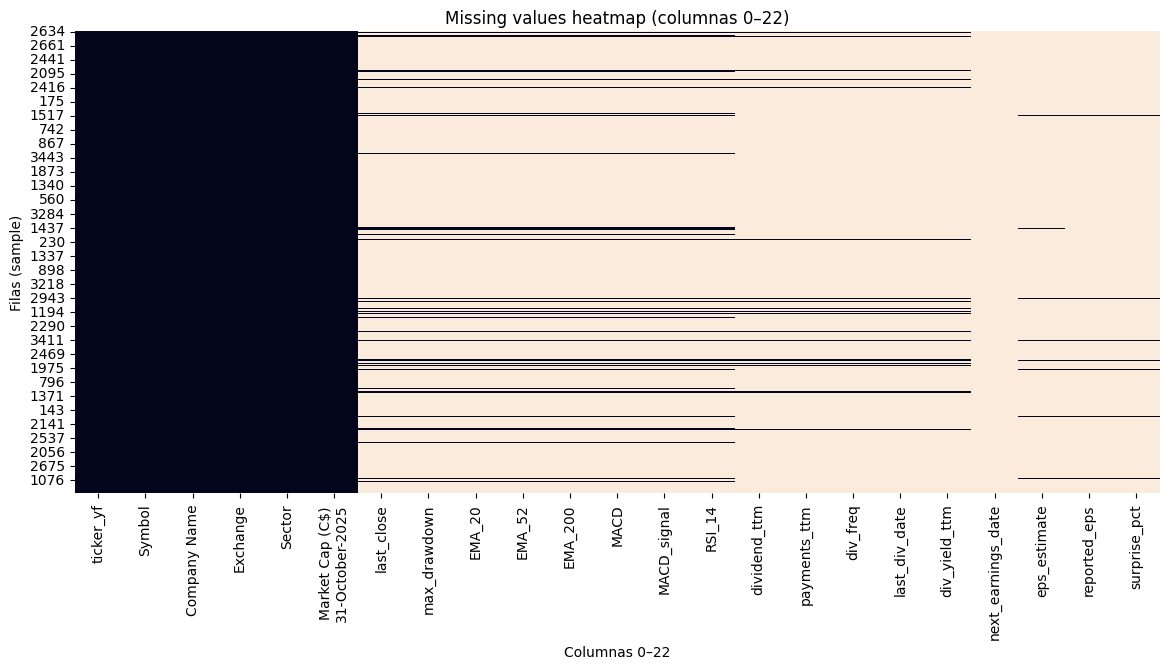

In [4]:
#eda

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import glob

def plot_missing_by_batches(df, sample_size=5000, cols_per_plot=40, random_state=42):
    """
    Hace heatmaps de NA usando:
    - una muestra de filas (sample_size)
    - columnas en batches de tamaño cols_per_plot
    """
    # 1) sample de filas (igual idea que antes)
    n_rows = len(df)
    sample_size = min(sample_size, n_rows)
    sample = df.sample(sample_size, random_state=random_state)

    n_cols = sample.shape[1]
    col_names = sample.columns.tolist()

    print(f"Sample usado para plots: {sample_size} filas, {n_cols} columnas")

    # 2) recorrer columnas en bloques
    for start in range(0, n_cols, cols_per_plot):
        end = min(start + cols_per_plot, n_cols)
        batch_cols = col_names[start:end]

        plt.figure(figsize=(14, 6))
        sns.heatmap(sample[batch_cols].isnull(), cbar=False)
        plt.title(f"Missing values heatmap (columnas {start}–{end-1})")
        plt.xlabel(f"Columnas {start}–{end-1}")
        plt.ylabel("Filas (sample)")
        plt.show()


def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name','dtypes']]
    summary['Missing'] = df.isnull().sum().values  
    summary['percentage missing'] = df.isnull().sum().values/df.shape[0] * 100    
    summary['Uniques'] = df.nunique().values
    summary['First Value'] = df.loc[0].values
    summary['Second Value'] = df.loc[1].values
    summary['Third Value'] = df.loc[2].values

    for name in summary['Name'].value_counts().index:
        summary.loc[summary['Name'] == name, 'Entropy'] = round(stats.entropy(df[name].value_counts(normalize=True), base=2),2) 

    return summary


display(resumetable(df_features))
plot_missing_by_batches(df_features, sample_size=5000, cols_per_plot=40)

In [5]:
pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

display(df_features.shape)
display(df_features.sort_values("dividend_ttm", ascending=False).head(100))

(3562, 23)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
90,BMO.TO,BMO,Bank of Montreal,TSX,Financial Services,1.245534e+11,192.169998,-0.165695,190.731058,185.658681,170.480513,2.633130,2.779832,57.054450,6.520000,4.0,Quarterly,2026-01-30,0.033928,NaT,3.07,3.04,-0.98
91,BNS.TO,BNS,Bank of Nova Scotia (The),TSX,Financial Services,1.138837e+11,103.160004,-0.125981,103.091235,100.770433,89.970480,0.846851,0.900588,50.695668,4.360000,4.0,Quarterly,2026-01-06,0.042264,NaT,2.00,2.06,3.14
180,ZEO.TO,ZEO,BMO Equal Weight Oil & Gas Index ETF,TSX,ETP,2.177377e+08,92.610001,-0.176228,87.059111,84.109317,80.000989,2.477212,1.974179,79.927302,2.744656,4.0,Quarterly,2025-12-30,0.029637,NaT,NaN,NaN,NaN
170,ZWT.TO,ZWT,BMO Covered Call Technology ETF,TSX,ETP,1.971875e+08,55.020000,-0.265045,57.510236,58.679426,57.061774,-1.128177,-0.818541,23.196432,2.740000,12.0,Monthly,2026-01-29,0.049800,NaT,NaN,NaN,NaN
167,ZWEN.TO,ZWEN,BMO Covered Call Energy ETF,TSX,ETP,1.185179e+08,31.480000,-0.190664,30.263144,29.380455,28.536795,0.675539,0.568753,76.675617,2.640000,12.0,Monthly,2026-01-29,0.083863,NaT,NaN,NaN,NaN
248,ZPAY.TO,ZPAY,BMO Premium Yield ETF,TSX,ETP,4.450735e+08,31.480000,-0.129080,31.997373,32.502442,32.931097,-0.304069,-0.285626,33.892630,2.451280,12.0,Monthly,2026-01-29,0.077868,NaT,NaN,NaN,NaN
97,BCE.TO,BCE,BCE Inc.,TSX,Comm. & Media,3.256919e+10,35.009998,-0.194773,34.574174,33.741094,32.942179,0.488352,0.557278,55.028455,2.312000,4.0,Quarterly,2025-12-15,0.066038,NaT,0.77,0.85,10.09
29,AEM.TO,AEM,Agnico Eagle Mines Limited,TSX,Mining,1.133419e+11,295.070007,-0.167319,278.780223,264.068638,220.848680,6.292957,6.319289,49.856392,2.239000,4.0,Quarterly,2025-12-01,0.007588,NaT,0.41,0.41,-0.70
197,ZWG.TO,ZWG,BMO Global High Dividend Covered Call ETF,TSX,ETP,2.793000e+08,34.759998,-0.155317,34.679165,34.463286,33.750766,0.164292,0.126337,55.066609,2.148560,12.0,Monthly,2026-01-29,0.061811,NaT,NaN,NaN,NaN
14,INCM.TO,INCM,Accelerate Diversified Credit Income Fund,TSX,ETP,6.929750e+07,13.880000,-0.326621,14.274650,14.746341,16.085059,-0.297220,-0.292279,32.034630,1.930000,12.0,Monthly,2026-01-30,0.139049,NaT,NaN,NaN,NaN


In [6]:
# 1) mira cuántos NaN o ceros tienes
print("NaN dividend_ttm:", df_features["dividend_ttm"].isna().mean())
print("0 dividend_ttm:", (df_features["dividend_ttm"].fillna(0) == 0).mean())
print("NaN div_yield_ttm:", df_features["div_yield_ttm"].isna().mean())

NaN dividend_ttm: 0.948905109489051
0 dividend_ttm: 0.948905109489051
NaN div_yield_ttm: 0.948905109489051


In [7]:
display(df_features.shape)


high_div = df_features[df_features["div_yield_ttm"].fillna(0) >= 0.04].copy()
high_div = high_div.sort_values("div_yield_ttm", ascending=False)

display(high_div.shape)
display(high_div[["ticker_yf","Company Name","Exchange","div_yield_ttm","dividend_ttm","payments_ttm","div_freq","last_close"]].head(50))
print("Total >=#%:", len(high_div))


(3562, 23)

(46, 23)

,ticker_yf,Company Name,Exchange,div_yield_ttm,dividend_ttm,payments_ttm,div_freq,last_close
14,INCM.TO,Accelerate Diversified Credit Income Fund,TSX,0.139049,1.930000,12.0,Monthly,13.880000
278,ZXCO.TO,BMO Target 2027 Canadian Corporate Bond ETF,TSX,0.106931,1.080000,3.0,Irregular,10.100000
292,ZPH.TO,BMO US Put Write Hedged to CAD ETF,TSX,0.103971,1.440000,12.0,Monthly,13.850000
291,ZPW.TO,BMO US Put Write ETF,TSX,0.099075,1.500000,12.0,Monthly,15.140000
167,ZWEN.TO,BMO Covered Call Energy ETF,TSX,0.083863,2.640000,12.0,Monthly,31.480000
136,PRM.TO,Big Pharma Split Corp.,TSX,0.082017,1.236000,12.0,Monthly,15.070000
135,BNK.TO,Big Banc Split Corp.,TSX,0.081865,1.440000,12.0,Monthly,17.590000
9,FAP.TO,abrdn Asia-Pacific Income Fund VCC,TSX,0.077978,0.216000,12.0,Monthly,2.770000
76,AI.TO,Atrium Mortgage Investments Corporation,TSX,0.077935,0.936000,12.0,Monthly,12.010000
248,ZPAY.TO,BMO Premium Yield ETF,TSX,0.077868,2.451280,12.0,Monthly,31.480000


Total >=#%: 46


In [8]:
df_features[df_features["ticker_yf"] == "BCE.TO"]

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
97,BCE.TO,BCE,BCE Inc.,TSX,Comm. & Media,3.256919e+10,35.009998,-0.194773,34.574174,33.741094,32.942179,0.488352,0.557278,55.028455,2.312,4.0,Quarterly,2025-12-15,0.066038,NaT,0.77,0.85,10.09


In [9]:

df_features[df_features["ticker_yf"] == "FAP.TO"]

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
9,FAP.TO,FAP,abrdn Asia-Pacific Income Fund VCC,TSX,Closed-End Funds,96223350.53,2.77,-0.077441,2.773615,2.81293,2.868793,-0.020377,-0.021796,42.105263,0.216,12.0,Monthly,2026-01-23,0.077978,NaT,NaN,NaN,NaN


In [10]:
df_features.head(10)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
0,IGBT.TO,IGBT,2028 Investment Grade Bond Trust,TSX,Closed-End Funds,3.978969e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
1,BTCQ.TO,BTCQ,3iQ Bitcoin ETF,TSX,ETP,2.611489e+08,14.600000,-0.509883,16.379473,18.353813,21.093531,-1.447500,-1.181443,27.765950,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
2,ETHQ.TO,ETHQ,3iQ Ether Staking ETF,TSX,ETP,9.630603e+07,10.860000,-0.618612,12.819736,15.054730,16.893096,-1.650268,-1.384370,25.186763,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
3,SOLQ.TO,SOLQ,3iQ Solana Staking ETF,TSX,ETP,2.530920e+08,9.260000,-0.690976,11.124383,13.408850,16.373981,-1.580036,-1.308276,24.736225,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
4,XRPQ.TO,XRPQ,3iQ XRP ETF,TSX,ETP,1.141848e+08,8.730000,-0.667269,10.017637,11.674539,14.046462,-1.114542,-0.965929,29.016614,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
5,VNP.TO,VNP,5N Plus Inc.,TSX,Clean Technology & Renewable Energy,1.786825e+09,27.719999,-0.334661,24.521460,21.786208,16.583018,2.155138,1.874114,76.111438,NaN,NaN,NaN,NaT,NaN,NaT,0.02,0.02,14.29
6,AW.TO,AW,A & W Food Services of Canada Inc.,TSX,Consumer Products & Services,8.771189e+08,36.509998,-0.167592,36.636068,37.034293,36.789986,-0.288083,-0.273541,54.813342,1.920,4.0,Quarterly,2025-12-15,0.052588,NaT,NaN,NaN,NaN
7,AAB.TO,AAB,Aberdeen International Inc.,TSX,Financial Services,4.805618e+06,0.030000,-0.250000,0.030758,0.031090,0.032240,-0.000412,-0.000206,50.000000,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN
8,ABRA.TO,ABRA,AbraSilver Resource Corp.,TSX,Mining,1.047174e+09,13.660000,-0.288136,13.302617,11.732894,8.081521,0.751613,0.761191,52.278821,NaN,NaN,NaN,NaT,NaN,NaT,-0.05,-0.10,-100.00
9,FAP.TO,FAP,abrdn Asia-Pacific Income Fund VCC,TSX,Closed-End Funds,9.622335e+07,2.770000,-0.077441,2.773615,2.812930,2.868793,-0.020377,-0.021796,42.105263,0.216,12.0,Monthly,2026-01-23,0.077978,NaT,NaN,NaN,NaN


In [11]:
features_for_kmeans = [
    "last_close",
    "dividend_ttm",
    "div_yield_ttm",
    "payments_ttm",
    "max_drawdown",
    "EMA_20",
    "EMA_52",
    "EMA_200",
    "RSI_14"
]


X = df_features[features_for_kmeans].copy()
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# dividendos explícitamente a 0
for c in ["dividend_ttm", "div_yield_ttm", "payments_ttm"]:
    if c in X_imputed.columns:
        X_imputed[c] = X[c].fillna(0)
        

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

df_features["cluster"] = clusters

pd.crosstab(
    df_features["cluster"],
    df_features["Sector"],
    normalize="index"
).round(2)


Sector,CPC,Clean Technology & Renewable Energy,Closed-End Funds,Comm. & Media,Consumer Products & Services,ETP,Financial Services,Industrial Products & Services,Life Sciences,Mining,Oil & Gas,Real Estate,SPAC,Technology,Utilities & Pipelines
cluster,,,,,,,,,,,,,,,
0,0.05,0.02,0.02,0.01,0.03,0.34,0.03,0.04,0.03,0.31,0.04,0.03,0.0,0.05,0.01
1,0.00,0.00,0.00,0.00,0.00,0.60,0.20,0.00,0.00,0.20,0.00,0.00,0.0,0.00,0.00
2,0.00,0.00,0.00,0.00,0.06,0.76,0.03,0.06,0.00,0.06,0.00,0.00,0.0,0.03,0.00
3,0.00,0.05,0.00,0.02,0.06,0.37,0.02,0.05,0.10,0.19,0.06,0.00,0.0,0.08,0.00
4,0.00,0.01,0.03,0.01,0.01,0.87,0.01,0.05,0.00,0.00,0.01,0.00,0.0,0.00,0.01


In [12]:
df_features.groupby("cluster")[features_for_kmeans].median().round(3)

,last_close,dividend_ttm,div_yield_ttm,payments_ttm,max_drawdown,EMA_20,EMA_52,EMA_200,RSI_14
cluster,,,,,,,,,
0,27.720,0.340,0.013,4.0,-0.180,27.600,27.485,26.341,50.593
1,282.830,0.600,0.003,1.0,-0.198,269.901,252.110,197.589,47.313
2,69.460,0.600,0.010,4.0,-0.177,71.104,69.367,65.615,44.474
3,6.630,0.116,0.018,4.0,-0.500,6.854,6.931,6.814,41.934
4,27.905,0.938,0.037,12.0,-0.093,27.894,27.613,26.455,61.702


In [13]:
cluster4=df_features[df_features["cluster"] == 4].sort_values("div_yield_ttm", ascending=False)
display(cluster4.shape)

display(cluster4)

(106, 24)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
14,INCM.TO,INCM,Accelerate Diversified Credit Income Fund,TSX,ETP,6.929750e+07,13.880000,-0.326621,14.274650,14.746341,16.085059,-0.297220,-0.292279,32.034630,1.930000,12.0,Monthly,2026-01-30,0.139049,NaT,NaN,NaN,NaN,4
278,ZXCO.TO,ZXCO,BMO Target 2027 Canadian Corporate Bond ETF,TSX,ETP,6.072010e+06,10.100000,-0.012770,10.092211,10.084602,10.054988,-0.000936,-0.000900,50.000000,1.080000,3.0,Irregular,2025-12-30,0.106931,NaT,NaN,NaN,NaN,4
292,ZPH.TO,ZPH,BMO US Put Write Hedged to CAD ETF,TSX,ETP,3.065175e+07,13.850000,-0.121769,14.084433,14.187957,14.252588,-0.092936,-0.068108,22.352994,1.440000,12.0,Monthly,2026-01-29,0.103971,NaT,NaN,NaN,NaN,4
291,ZPW.TO,ZPW,BMO US Put Write ETF,TSX,ETP,8.935596e+07,15.140000,-0.117288,15.414424,15.609325,15.724092,-0.153186,-0.129230,29.720260,1.500000,12.0,Monthly,2026-01-29,0.099075,NaT,NaN,NaN,NaN,4
167,ZWEN.TO,ZWEN,BMO Covered Call Energy ETF,TSX,ETP,1.185179e+08,31.480000,-0.190664,30.263144,29.380455,28.536795,0.675539,0.568753,76.675617,2.640000,12.0,Monthly,2026-01-29,0.083863,NaT,NaN,NaN,NaN,4
136,PRM.TO,PRM,Big Pharma Split Corp.,TSX,Closed-End Funds,2.897932e+07,15.070000,-0.212009,14.479412,14.026748,12.981869,0.254414,0.205258,70.157067,1.236000,12.0,Monthly,2026-01-30,0.082017,NaT,NaN,NaN,NaN,4
135,BNK.TO,BNK,Big Banc Split Corp.,TSX,Closed-End Funds,3.714561e+07,17.590000,-0.089139,17.243503,17.050180,16.025425,0.117775,0.083696,63.690488,1.440000,12.0,Monthly,2026-01-30,0.081865,NaT,NaN,NaN,NaN,4
9,FAP.TO,FAP,abrdn Asia-Pacific Income Fund VCC,TSX,Closed-End Funds,9.622335e+07,2.770000,-0.077441,2.773615,2.812930,2.868793,-0.020377,-0.021796,42.105263,0.216000,12.0,Monthly,2026-01-23,0.077978,NaT,NaN,NaN,NaN,4
76,AI.TO,AI,Atrium Mortgage Investments Corporation,TSX,Financial Services,6.471852e+08,12.010000,-0.066911,11.720951,11.634001,11.433692,0.059550,0.033398,64.705892,0.936000,12.0,Monthly,2026-01-30,0.077935,NaT,0.29,0.31,6.90,4
248,ZPAY.TO,ZPAY,BMO Premium Yield ETF,TSX,ETP,4.450735e+08,31.480000,-0.129080,31.997373,32.502442,32.931097,-0.304069,-0.285626,33.892630,2.451280,12.0,Monthly,2026-01-29,0.077868,NaT,NaN,NaN,NaN,4


In [14]:
cluster3=df_features[df_features["cluster"] == 3].sort_values("div_yield_ttm", ascending=False)
display(cluster3.shape)

display(cluster3)

(62, 24)

,ticker_yf,Symbol,Company Name,Exchange,Sector,Market Cap (C$)\n31-October-2025,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
26,AFN.TO,AFN,AG Growth International Inc.,TSX,Industrial Products & Services,1.100857e+09,27.480000,-0.582314,28.716202,28.050184,32.198413,0.329557,0.836913,31.432043,0.600,4.0,Quarterly,2025-12-31,0.021834,NaT,0.47,0.92,95.15,3
37,ASTL.TO,ASTL,Algoma Steel Group Inc.,TSX,Industrial Products & Services,6.149121e+08,6.580000,-0.611642,6.226695,6.030358,6.816647,0.155173,0.124099,57.634408,0.142,2.0,Semi-Annual,2025-05-13,0.021581,NaT,-0.46,-0.64,-39.13,3
96,BTE.TO,BTE,Baytex Energy Corp.,TSX,Oil & Gas,2.604595e+09,4.750000,-0.431319,4.708033,4.497872,3.771411,0.076125,0.085574,55.782322,0.092,4.0,Quarterly,2025-12-15,0.019368,NaT,0.23,0.15,-34.07,3
138,BIR.TO,BIR,Birchcliff Energy Ltd.,TSX,Oil & Gas,1.786288e+09,6.920000,-0.267949,7.121950,7.128679,6.752523,-0.056042,-0.027758,35.761593,0.120,4.0,Quarterly,2025-12-15,0.017341,NaT,0.60,0.81,35.00,3
87,BTO.TO,BTO,B2Gold Corp.,TSX,Mining,8.160732e+09,7.350000,-0.355769,7.032216,6.734205,5.909126,0.177889,0.177367,50.101830,0.112,4.0,Quarterly,2025-12-02,0.015238,NaT,0.07,0.10,44.74,3
21,DRX.TO,DRX,ADF Group Inc.,TSX,Industrial Products & Services,1.184649e+08,9.740000,-0.398618,9.233301,8.763525,8.215625,0.327450,0.246345,68.472900,0.040,2.0,Semi-Annual,2025-09-26,0.004107,NaT,NaN,NaN,NaN,3
1,BTCQ.TO,BTCQ,3iQ Bitcoin ETF,TSX,ETP,2.611489e+08,14.600000,-0.509883,16.379473,18.353813,21.093531,-1.447500,-1.181443,27.765950,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,3
2,ETHQ.TO,ETHQ,3iQ Ether Staking ETF,TSX,ETP,9.630603e+07,10.860000,-0.618612,12.819736,15.054730,16.893096,-1.650268,-1.384370,25.186763,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,3
3,SOLQ.TO,SOLQ,3iQ Solana Staking ETF,TSX,ETP,2.530920e+08,9.260000,-0.690976,11.124383,13.408850,16.373981,-1.580036,-1.308276,24.736225,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,3
4,XRPQ.TO,XRPQ,3iQ XRP ETF,TSX,ETP,1.141848e+08,8.730000,-0.667269,10.017637,11.674539,14.046462,-1.114542,-0.965929,29.016614,NaN,NaN,NaN,NaT,NaN,NaT,NaN,NaN,NaN,3


# LSE

In [15]:
import pandas as pd

# Cargar archivos LSE
df_sets = pd.read_excel("list_of_sets_securities_55.xlsx")
df_setsqx = pd.read_excel("list_of_setsqx_ccp_securities_55.xlsx")

# Agregar metadata
df_sets["market"] = "SETS"
df_setsqx["market"] = "SETSqx"
df_sets["exchange"] = "LSE"
df_setsqx["exchange"] = "LSE"

# Unir
df_lse = pd.concat([df_sets, df_setsqx], ignore_index=True)

display(df_lse.shape)
display(df_lse.head(10))

d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(1336, 23)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,market,exchange
0,NaN,Stock List for SETS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SETS,LSE
1,NaN,File last updated on 08/12/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SETS,LSE
2,NaN,Segment,Sector,Issuer Name,ISIN,Security Type,MiFIR Identifier,Currency,Trading Parameter Code,Price Tick Table ID,Country of Register,Mnemonic,Short Name,Long Name,Professional Investor Only,EMS,Max Spread Floor,Max Spread Perc.,ADT / PTS (EU),ADT / PTS (UK),Issuer Version Start Date,SETS,LSE
3,NaN,SET1,FE10,3I GROUP PLC,GB00B1YW4409,DE,SHRS,GBX,TP_1,TM_47,GB,III,3I GRP.,ORD 73 19/22P,N,500,1,5,0,126536358,2025-01-22 00:00:00,SETS,LSE
4,NaN,SET1,FE10,ANGLO AMERICAN PLC,GB00BTK05J60,DE,SHRS,GBX,TP_1,TM_47,GB,AAL,ANGLO AMERICAN,ORD USD0.623855311355311,N,1000,1,5,23506714,237766594,2025-06-04 00:00:00,SETS,LSE
5,NaN,SET1,FE10,ASTRAZENECA PLC,GB0009895292,DE,SHRS,GBX,TP_1,TM_48,GB,AZN,ASTRAZENECA,ORD SHS $0.25,N,200,1,5,226956823,596734935,2018-02-26 00:00:00,SETS,LSE
6,NaN,SET1,FE10,BAE SYSTEMS PLC,GB0002634946,DE,SHRS,GBX,TP_1,TM_47,GB,BA.,BAE SYS.,ORD 2.5P,N,1000,1,5,0,185273586,2019-09-16 00:00:00,SETS,LSE
7,NaN,SET1,FE10,BARCLAYS PLC,GB0031348658,DE,SHRS,GBX,TP_1,TM_48,GB,BARC,BARCLAYS,ORD 25P,N,5000,1,5,57668151,225127415,2018-04-05 00:00:00,SETS,LSE
8,NaN,SET1,FE10,BP PLC,GB0007980591,DE,SHRS,GBX,TP_1,TM_48,GB,BP.,BP,$0.25,N,5000,1,5,0,400970992,2018-01-02 00:00:00,SETS,LSE
9,NaN,SET1,FE10,BRITISH AMERICAN TOBACCO PLC,GB0002875804,DE,SHRS,GBX,TP_1,TM_47,GB,BATS,BR.AMER.TOB.,ORD 25P,N,500,1,5,63191965,257948673,2018-01-02 00:00:00,SETS,LSE


In [16]:
import pandas as pd

def load_lse_stocklist(path, market_name):
    df = pd.read_excel(path, header=3)          # <- la fila con headers reales
    df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")], errors="ignore")

    # Normaliza nombres
    df.columns = [str(c).strip() for c in df.columns]

    # Qué columnas usar (según tu screenshot)
    df = df.rename(columns={
        "Mnemonic": "Symbol",
        "Issuer Name": "Company Name",
        "Currency": "Currency",
    })

    # Quita filas vacías
    df = df.dropna(subset=["Symbol"])

    # Yahoo Finance para LSE suele usar sufijo .L
    df["ticker_yf"] = df["Symbol"].astype(str).str.strip() + ".L"

    # Metadata
    df["exchange"] = "LSE"
    df["market"] = market_name

    return df[["ticker_yf", "Symbol", "Company Name", "exchange", "market", "Currency", "ISIN"]].drop_duplicates()

df_sets   = load_lse_stocklist("list_of_sets_securities_55.xlsx", "SETS")
df_setsqx = load_lse_stocklist("list_of_setsqx_ccp_securities_55.xlsx", "SETSqx")

df_lse_final = pd.concat([df_sets, df_setsqx], ignore_index=True)
df_lse_final = df_lse_final.drop_duplicates(subset=["ticker_yf", "ISIN"], keep="first")

display(df_lse_final.shape)
display(df_lse_final.head(10))


d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
d:\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(1330, 7)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN
0,III.L,III,3I GROUP PLC,LSE,SETS,GBX,GB00B1YW4409
1,AAL.L,AAL,ANGLO AMERICAN PLC,LSE,SETS,GBX,GB00BTK05J60
2,AZN.L,AZN,ASTRAZENECA PLC,LSE,SETS,GBX,GB0009895292
3,BA..L,BA.,BAE SYSTEMS PLC,LSE,SETS,GBX,GB0002634946
4,BARC.L,BARC,BARCLAYS PLC,LSE,SETS,GBX,GB0031348658
5,BP..L,BP.,BP PLC,LSE,SETS,GBX,GB0007980591
6,BATS.L,BATS,BRITISH AMERICAN TOBACCO PLC,LSE,SETS,GBX,GB0002875804
7,CCEP.L,CCEP,COCA-COLA EUROPACIFIC PARTNERS PLC,LSE,SETS,GBX,GB00BDCPN049
8,CPG.L,CPG,COMPASS GROUP PLC,LSE,SETS,GBX,GB00BD6K4575
9,DGE.L,DGE,DIAGEO PLC,LSE,SETS,GBX,GB0002374006


In [17]:
# 1) Asegura tipos
df_lse_final["ticker_yf"] = df_lse_final["ticker_yf"].astype(str).str.strip()

# 2) (Opcional) filtra tickers raros antes de pedir data
df_lse_final = df_lse_final.dropna(subset=["ticker_yf"]).drop_duplicates("ticker_yf")

meandataerrorvaldiation=df_lse_final["ticker_yf"].str.contains(r"\.\.", na=False).mean()
if meandataerrorvaldiation>0:
    df_lse_final["ticker_yf"] = (
        df_lse_final["ticker_yf"]
        .str.strip()
        .str.replace(r"\.\.", ".", regex=True)   # BP..L → BP.L
        .str.replace(r"\.A\.L$", "-A.L", regex=True)
        .str.replace(r"\.B\.L$", "-B.L", regex=True)
)
    
df_lse_final["ticker_yf"].str.contains(r"\.\.", na=False).mean()

0.0

In [18]:


# 3) Aplica tu pipeline robusto (esto debería agregar dividend_ttm, payments_ttm, div_yield_ttm, etc.)
df_lse_features, df_lse_div_events = build_features_cached(
                                        companies=df_lse_final.copy(),
                                        cache_key="lse",
                                        period="1y",
                                        stale_days=7
                                    )

# 4) Revisa resultados
cols_check = ["ticker_yf","Symbol","Company Name","exchange","market","Currency",
              "dividend_ttm","payments_ttm","div_freq","div_yield_ttm","last_div_date"]
display(df_lse_features[ [c for c in cols_check if c in df_lse_features.columns] ].head(20))

display(df_lse_features.shape)
display(df_lse_features.isna()[["dividend_ttm","payments_ttm","div_yield_ttm"]].mean())


⬇️ Recalculando (sin cache o stale): lse



19 Failed downloads:
['ARB.L', 'PNPL.L', 'SEFA.L', 'EUZ.L', 'ALTR.L', 'EVR.L', 'MHN.L', 'TRX.L', 'AEEE.L', 'OCN.L', 'AVAW.L', 'IGLD.L']: YFPricesMissingError('possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")')
['GV1A.L', 'GV2A.L', 'DNE.L']: YFPricesMissingError('possibly delisted; no price data found  (period=1y)')
['MAY.L']: Timeout('Failed to perform, curl: (28) Resolving timed out after 10009 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['CGO.L']: Timeout('Failed to perform, curl: (28) Resolving timed out after 10004 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['SRE.L']: Timeout('Failed to perform, curl: (28) Resolving timed out after 10006 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')
['CORA.L']: Timeout('Failed to perform, curl: (28) Resolving timed out after 10001 milliseconds. See https:

Tickers input: 1330 | Price ok: 1315 | Fallback used: 4 | Div events rows: 34323
💾 Cache guardado: lse_features.csv + lse_div_events.csv


,ticker_yf,Symbol,Company Name,exchange,market,Currency,dividend_ttm,payments_ttm,div_freq,div_yield_ttm,last_div_date
0,III.L,III,3I GROUP PLC,LSE,SETS,GBX,79.000000,2.0,Semi-Annual,0.022992,2025-11-27
1,AAL.L,AAL,ANGLO AMERICAN PLC,LSE,SETS,GBX,24.016300,2.0,Semi-Annual,0.006697,2025-08-21
2,AZN.L,AZN,ASTRAZENECA PLC,LSE,SETS,GBX,244.700005,2.0,Semi-Annual,0.016186,2025-08-07
3,BA.L,BA.,BAE SYSTEMS PLC,LSE,SETS,GBX,34.100001,2.0,Semi-Annual,0.017327,2025-10-23
4,BARC.L,BARC,BARCLAYS PLC,LSE,SETS,GBX,8.500000,2.0,Semi-Annual,0.018722,2025-08-07
5,BP.L,BP.,BP PLC,LSE,SETS,GBX,24.509000,4.0,Quarterly,0.053165,2025-11-13
6,BATS.L,BATS,BRITISH AMERICAN TOBACCO PLC,LSE,SETS,GBX,240.240000,4.0,Quarterly,0.055177,2025-12-29
7,CCEP.L,CCEP,COCA-COLA EUROPACIFIC PARTNERS PLC,LSE,SETS,GBX,177.353520,2.0,Semi-Annual,0.024229,2025-11-13
8,CPG.L,CPG,COMPASS GROUP PLC,LSE,SETS,GBX,48.449999,2.0,Semi-Annual,0.023542,2026-01-15
9,DGE.L,DGE,DIAGEO PLC,LSE,SETS,GBX,79.390000,2.0,Semi-Annual,0.043525,2025-10-16


(1330, 24)

dividend_ttm     0.474436
payments_ttm     0.474436
div_yield_ttm    0.474436
dtype: float64

In [19]:

df_lse_features.sort_values("div_yield_ttm", ascending=False).head(20)


,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
153,AERS.L,AERS,AQUILA EUROPEAN RENEWABLES PLC,LSE,SETS,GBX,GB00BK6RLF66,0.219500,-0.601648,0.247525,0.282721,0.377532,-0.020678,-0.019795,34.615382,10.386058,5.0,Irregular,2026-01-20,47.316892,NaT,NaN,NaN,NaN
1199,FTF.L,FTF,FORESIGHT ENTERPRISE VCT PLC,LSE,SETSqx,GBX,GB00B07YBS95,0.468000,-0.991541,16.394804,21.929016,31.187089,-7.236894,-3.116646,0.000000,5.900000,2.0,Semi-Annual,2025-07-03,12.606838,NaT,NaN,NaN,NaN
1318,USFP.L,USFP,US SOLAR FUND PLC,LSE,SETSqx,GBX,GB00BJCWFX49,0.241000,-0.258462,0.243381,0.252269,0.273412,-0.003317,-0.004019,0.000000,2.064300,4.0,Quarterly,2025-12-04,8.565560,NaT,NaN,NaN,NaN
1215,GHV2.L,GHV2,GRESHAM HOUSE INC & GRWTH 2 VCT PLC,LSE,SETSqx,GBX,GB00B01WL239,0.500500,-0.990731,24.954116,38.043957,46.587950,-13.389050,-8.780193,0.900011,4.000000,2.0,Semi-Annual,2025-09-18,7.992008,NaT,NaN,NaN,NaN
1266,OFG.L,OFG,OCTOPUS FUTURE GENERATIONS VCT PLC,LSE,SETSqx,GBX,GB00BNGFHX14,0.795000,-0.990592,0.795004,0.846188,2.482457,-0.000154,-0.000226,NaN,5.600000,1.0,Annual,2025-09-04,7.044026,NaT,NaN,NaN,NaN
1300,SVCT.L,SVCT,SENECA GROWTH CAPITAL VCT PLC,LSE,SETSqx,GBX,GB00BG13MH08,0.440000,-0.990435,0.738653,3.963888,6.145494,-0.803240,-1.153424,NaN,3.000000,2.0,Semi-Annual,2025-12-04,6.818182,NaT,NaN,NaN,NaN
157,BPCP.L,BPCP,BIOPHARMA CREDIT PLC,LSE,SETS,GBX,GB00BDGKMY29,0.691000,-0.078684,0.681530,0.681871,0.677780,0.001281,-0.000573,60.273969,4.689846,3.0,Irregular,2025-09-25,6.787043,NaT,NaN,NaN,NaN
1155,BFSP.L,BFSP,BLACKFINCH SPRING VCT PLC,LSE,SETSqx,GBX,GB00BKV46W45,0.885000,-0.991061,1.215588,4.632561,25.285059,-0.816651,-1.162544,0.000000,5.200000,2.0,Semi-Annual,2025-07-03,5.875706,NaT,NaN,NaN,NaN
1127,CRWC.L,CRWC,ALBION CROWN VCT PLC,LSE,SETSqx,GBX,GB00BSPT6546,0.371000,-0.991209,10.096376,19.137613,28.711508,-7.683863,-6.402832,0.000000,2.080000,2.0,Semi-Annual,2025-11-06,5.606469,NaT,NaN,NaN,NaN
1126,CRWN.L,CRWN,ALBION CROWN VCT PLC,LSE,SETSqx,GBX,GB0002577434,0.281000,-0.990539,3.422122,10.013531,16.258450,-3.932449,-4.490292,NaN,1.540000,2.0,Semi-Annual,2025-11-06,5.480427,NaT,NaN,NaN,NaN


In [20]:
features_for_kmeans = [
    "last_close",
    "dividend_ttm",
    "div_yield_ttm",
    "payments_ttm",
    "max_drawdown",
    "EMA_20",
    "EMA_52",
    "EMA_200",
    "RSI_14"
]


X = df_lse_features[features_for_kmeans].copy()
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# dividendos explícitamente a 0
for c in ["dividend_ttm", "div_yield_ttm", "payments_ttm"]:
    if c in X_imputed.columns:
        X_imputed[c] = X[c].fillna(0)
        

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

df_lse_features["cluster"] = clusters

pd.crosstab(
    df_features["cluster"],
    df_features["Sector"],
    normalize="index"
).round(2)

Sector,CPC,Clean Technology & Renewable Energy,Closed-End Funds,Comm. & Media,Consumer Products & Services,ETP,Financial Services,Industrial Products & Services,Life Sciences,Mining,Oil & Gas,Real Estate,SPAC,Technology,Utilities & Pipelines
cluster,,,,,,,,,,,,,,,
0,0.05,0.02,0.02,0.01,0.03,0.34,0.03,0.04,0.03,0.31,0.04,0.03,0.0,0.05,0.01
1,0.00,0.00,0.00,0.00,0.00,0.60,0.20,0.00,0.00,0.20,0.00,0.00,0.0,0.00,0.00
2,0.00,0.00,0.00,0.00,0.06,0.76,0.03,0.06,0.00,0.06,0.00,0.00,0.0,0.03,0.00
3,0.00,0.05,0.00,0.02,0.06,0.37,0.02,0.05,0.10,0.19,0.06,0.00,0.0,0.08,0.00
4,0.00,0.01,0.03,0.01,0.01,0.87,0.01,0.05,0.00,0.00,0.01,0.00,0.0,0.00,0.01


In [21]:
df_lse_features.groupby("cluster")[features_for_kmeans].median().round(3)

,last_close,dividend_ttm,div_yield_ttm,payments_ttm,max_drawdown,EMA_20,EMA_52,EMA_200,RSI_14
cluster,,,,,,,,,
0,241.10,8.800,0.035,2.0,-0.212,240.607,232.730,221.474,56.126
1,3731.50,91.772,0.024,2.0,-0.229,3551.504,3374.687,3336.292,60.411
2,11.75,3.600,0.056,2.0,-0.561,12.802,12.715,13.582,41.105
3,13926.50,425.000,0.028,3.0,-0.180,13634.207,13839.839,14666.862,50.248
4,0.22,10.386,47.317,5.0,-0.602,0.248,0.283,0.378,34.615


In [22]:
cluster4=df_lse_features[df_lse_features["cluster"] == 4].sort_values("div_yield_ttm", ascending=False)
display(cluster4.shape)

display(cluster4)



(1, 25)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
153,AERS.L,AERS,AQUILA EUROPEAN RENEWABLES PLC,LSE,SETS,GBX,GB00BK6RLF66,0.2195,-0.601648,0.247525,0.282721,0.377532,-0.020678,-0.019795,34.615382,10.386058,5.0,Irregular,2026-01-20,47.316892,NaT,NaN,NaN,NaN,4


dasta looks akward but  after verification in real wwold wi trading view all looks good

https://es.tradingview.com/chart/AqFACMx7/?symbol=LSE%3AHYG

In [23]:
cluster0=df_lse_features[df_lse_features["cluster"] == 0].sort_values("div_yield_ttm", ascending=False)
display(cluster0.shape)

display(cluster0.head(20))

(630, 25)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,ISIN,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct,cluster
1318,USFP.L,USFP,US SOLAR FUND PLC,LSE,SETSqx,GBX,GB00BJCWFX49,0.241000,-0.258462,0.243381,0.252269,0.273412,-0.003317,-0.004019,0.000000,2.064300,4.0,Quarterly,2025-12-04,8.565560,NaT,NaN,NaN,NaN,0
157,BPCP.L,BPCP,BIOPHARMA CREDIT PLC,LSE,SETS,GBX,GB00BDGKMY29,0.691000,-0.078684,0.681530,0.681871,0.677780,0.001281,-0.000573,60.273969,4.689846,3.0,Irregular,2025-09-25,6.787043,NaT,NaN,NaN,NaN,0
132,PEYS.L,PEYS,PARTNERS GROUP PRIVATE EQUITY LD,LSE,SETS,GBX,GG00B28C2R28,8.530000,-0.112500,8.782814,8.915268,8.861288,-0.118984,-0.093979,18.823573,33.110100,1.0,Annual,2025-11-13,3.881606,NaT,NaN,NaN,NaN,0
332,ASLI.L,ASLI,ABRDN EUROPEAN LOGISTICS INCOME PLC,LSE,SETS,GBX,GB00BD9PXH49,27.150000,-0.631336,27.083797,28.734130,39.363625,-0.251439,-0.398997,50.980376,42.440000,8.0,Irregular,2025-12-15,1.563168,NaT,NaN,NaN,NaN,0
144,VSL.L,VSL,VPC SPECIALTY LENDING INVESTMENTS,LSE,SETS,GBX,GB00BVG6X439,13.450000,-0.562706,13.654079,14.437896,16.987341,-0.371274,-0.442376,57.142857,18.502300,4.0,Quarterly,2025-12-11,1.375636,NaT,NaN,NaN,NaN,0
493,TMIP.L,TMIP,TAYLOR MARITIME LIMITED,LSE,SETS,GBX,GG00BP2NJT37,61.000000,-0.308642,61.412129,62.278233,64.119005,-0.438270,-0.678592,46.551721,75.154475,5.0,Irregular,2026-02-02,1.232041,NaT,NaN,NaN,NaN,0
331,ADIG.L,ADIG,ABRDN DIVERSIFIED INCOME AND GROWTH,LSE,SETS,GBX,GB0001297562,28.100000,-0.464903,27.883238,29.165600,37.219885,0.068015,-0.040017,60.975653,20.500000,2.0,Semi-Annual,2025-11-12,0.729537,NaT,NaN,NaN,NaN,0
152,AERI.L,AERI,AQUILA EUROPEAN RENEWABLES PLC,LSE,SETS,EUR,GB00BK6RLF66,0.245000,-0.621914,0.275555,0.317265,0.432215,-0.023623,-0.023753,11.594259,0.119916,5.0,Irregular,2026-01-20,0.489453,NaT,NaN,NaN,NaN,0
1315,UAV.L,UAV,UNICORN AIM VCT PLC,LSE,SETSqx,GBX,GB00B1RTFN43,75.000000,-0.990613,70.551012,59.432300,53.482345,5.301903,6.771613,100.000000,29.500000,3.0,Irregular,2026-01-22,0.393333,NaT,NaN,NaN,NaN,0
1246,MRV.L,MRV,MAVEN RENOVAR VCT PLC,LSE,SETSqx,GBX,GB00B641BB82,57.000000,-0.202797,58.011063,58.413870,60.899222,-0.393141,-0.175671,0.000000,15.000000,2.0,Semi-Annual,2025-10-16,0.263158,NaT,NaN,NaN,NaN,0


In [24]:
import pandas as pd
df_nyse = pd.read_csv("nyse-listed.csv")

df_nyse.head()

,ACT Symbol,Company Name
0,A,"Agilent Technologies, Inc. Common Stock"
1,AA,Alcoa Corporation Common Stock
2,AAM,AA Mission Acquisition Corp. Class A Ordinary Shares
3,AAM.U,"AA Mission Acquisition Corp. Units, each consisting of one Class A Ordinary Share and one"
4,AAM.W,"AA Mission Acquisition Corp. Warrants, each whole warrant entitles the holder to purchase one Class A ordinary share at a price of $11.50 per share"


In [25]:
df_nyse["ticker_yf"] = df_nyse["ACT Symbol"].astype(str).str.strip()

df_nyse["Symbol"] = df_nyse["ACT Symbol"]
df_nyse["exchange"] = "NYSE"
df_nyse["market"] = "NYSE"
df_nyse["Currency"] = "USD"

display(df_nyse.shape)

df_nyse_final = df_nyse[[
    "ticker_yf",
    "Symbol",
    "Company Name",
    "exchange",
    "market",
    "Currency"
]].drop_duplicates()

display(df_nyse_final.shape)

(2888, 7)

(2888, 6)

Dataset Shape: (2888, 6)


,Name,dtypes,Missing,percentage missing,Uniques,First Value,Second Value,Third Value,Entropy
0,ticker_yf,object,0,0.0,2888,A,AA,AAM,11.50
1,Symbol,object,0,0.0,2888,A,AA,AAM,11.50
2,Company Name,object,0,0.0,2847,"Agilent Technologies, Inc. Common Stock",Alcoa Corporation Common Stock,AA Mission Acquisition Corp. Class A Ordinary Shares,11.46
3,exchange,object,0,0.0,1,NYSE,NYSE,NYSE,0.00
4,market,object,0,0.0,1,NYSE,NYSE,NYSE,0.00
5,Currency,object,0,0.0,1,USD,USD,USD,0.00


Sample usado para plots: 2888 filas, 6 columnas


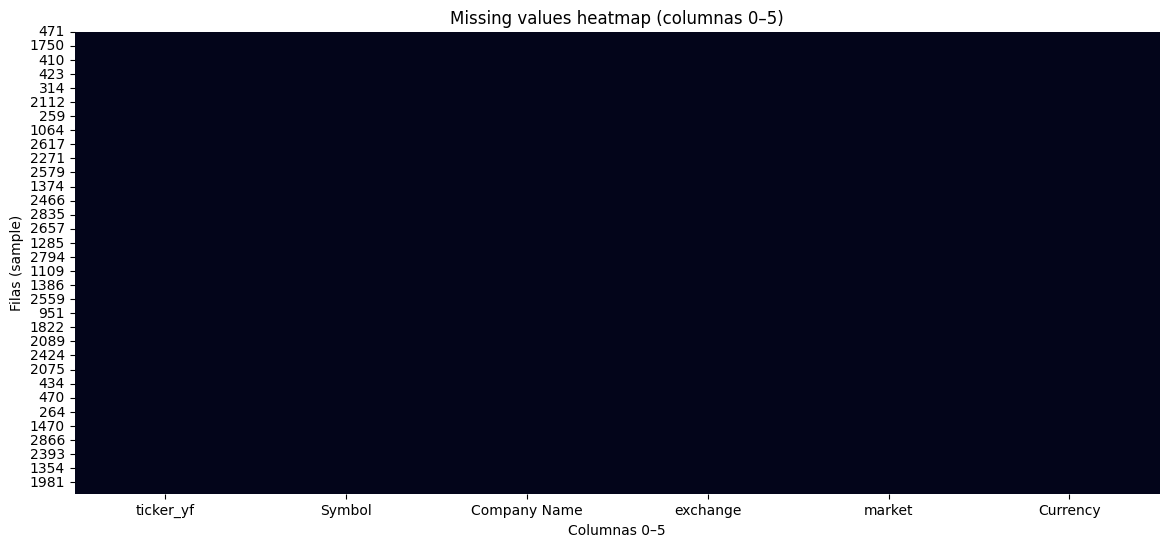

In [26]:
display(resumetable(df_nyse_final))
plot_missing_by_batches(df_nyse_final, sample_size=5000, cols_per_plot=40)

In [27]:
df_nyse_features, df_nyse_div_events = build_features_cached(
    companies=df_nyse_final.copy(),   # tu df de compañías NYSE
    cache_key="nyse",
    period="1y",
    stale_days=7
)

⬇️ Recalculando (sin cache o stale): nyse



1443 Failed downloads:
['NEE$T', 'NREF$A', 'KREF$A', 'INN$F', 'MTB$H', 'EPR$G', 'LXP$C', 'MAA$I', 'BHR$D', 'MER$K', 'BAC$L', 'ACR$C', 'SES.W', 'SB$D', 'HVT.A', 'VNO$O', 'SF$B', 'GPMT$A', 'DRH$A', 'GS$C', 'CODI$C', 'SPE$C', 'TE.W', 'GNL$A', 'CMS$C', 'CFG$I', 'RNR$F', 'KIM$L', 'MET$E', 'TWO$C', 'PSA$F', 'GMRE$B', 'NLY$G', 'KEY$I', 'SEAL$B', 'CIM$D', 'WFC$C', 'PEB$G', 'PRIF$K', 'SNV$D', 'SB$C', 'WRB$H', 'ARR$C', 'BKKT.W', 'MOG.B', 'CIM$A', 'ACR$D', 'SNV$E', 'RF$E', 'AAM.W', 'BAC$B', 'PAII.U', 'IIPR$A', 'NEE$S', 'OAK$B', 'BAC$K', 'WBS$G', 'GSL$B', 'IONQ.W', 'NOTE.W', 'PSEC$A', 'WFC$A', 'T$C', 'MS$E', 'SOUL.U', 'PMT$A', 'WFC$Y', 'DLNG$A', 'RITM$A', 'DBRG$I', 'MFA$C', 'TEN$E', 'PRIF$L', 'BAC$Q', 'BAC$M', 'OPFI.W', 'SPG$J', 'UMH$D', 'RJF$B', 'BKSY.W', 'TDS$U', 'DLR$K', 'JXN$A', 'AAM.U', 'VACI.W', 'CDR$C', 'TRTN$F', 'TFC$R', 'PSA$N', 'JPM$J', 'SCE$L', 'BIP$A', 'OAK$A', 'BEP$A', 'CUBI$F', 'HYAC.U', 'FCRS.U', 'UWMC.W', 'BANC$F', 'BH.A', 'BML$H', 'NSA$B', 'PSA$M', 'GLOP$B', 'AXS$E', 'NLY$I', 'AG

Tickers input: 2888 | Price ok: 1445 | Fallback used: 0 | Div events rows: 106407
💾 Cache guardado: nyse_features.csv + nyse_div_events.csv


In [28]:
cols_check = [
    "ticker_yf","Symbol","Company Name",
    "exchange","market","Currency",
    "last_close","dividend_ttm",
    "payments_ttm","div_freq","div_yield_ttm",
    "max_drawdown"
]

display(
    df_nyse_features[[c for c in cols_check if c in df_nyse_features.columns]]
    .sort_values("div_yield_ttm", ascending=False)
    .head(20)
)

df_nyse_features.shape


,ticker_yf,Symbol,Company Name,exchange,market,Currency,last_close,dividend_ttm,payments_ttm,div_freq,div_yield_ttm,max_drawdown
891,ELME,ELME,Elme Communities Common Stock,NYSE,NYSE,USD,2.180000,15.210,4.0,Quarterly,6.977064,-0.876923
1821,NLOP,NLOP,Net Lease Office Properties Common Shares of Beneficial Interest,NYSE,NYSE,USD,19.799999,12.300,3.0,Irregular,0.621212,-0.452135
1757,MVO,MVO,MV Oil Trust Units of Beneficial Interests,NYSE,NYSE,USD,1.460000,0.805,4.0,Quarterly,0.551370,-0.843077
100,AIV,AIV,Apartment Investment and Management Company Common Stock,NYSE,NYSE,USD,5.820000,2.230,1.0,Annual,0.383162,-0.419604
844,ECC,ECC,Eagle Point Credit Company Inc. Common Stock,NYSE,NYSE,USD,4.470000,1.680,12.0,Monthly,0.375839,-0.495485
1316,HUYA,HUYA,"HUYA Inc. American depositary shares, each representing one Class A ordinary share",NYSE,NYSE,USD,4.280000,1.470,1.0,Annual,0.343458,-0.488987
2424,SPMC,SPMC,"Sound Point Meridian Capital, Inc. Common Stock",NYSE,NYSE,USD,11.010000,2.990,12.0,Monthly,0.271571,-0.502035
843,ECAT,ECAT,BlackRock ESG Capital Allocation Term Trust Common Shares of Beneficial Interest,NYSE,NYSE,USD,15.220000,3.479,12.0,Monthly,0.228581,-0.171531
2167,RC,RC,Ready Capital Corporation Common Stock,NYSE,NYSE,USD,1.690000,0.385,4.0,Quarterly,0.227811,-0.760462
2010,PDX,PDX,PIMCO Dynamic Income Strategy Fund Common Shares of Beneficial Interest,NYSE,NYSE,USD,20.110001,4.566,13.0,Monthly,0.227051,-0.283559


(2888, 23)

In [29]:
df_all = pd.concat(
    [df_features, df_lse_features, df_nyse_features],
    ignore_index=True
)

df_all.shape

(7780, 28)

In [30]:
pd.set_option("display.max_rows", 600)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

df_filtered = df_nyse_features[
    df_nyse_features["ticker_yf"].str.contains("AG|NNN|JEQP", case=False, na=False)
]

# display(df_filtered)

high_div = df_nyse_features[df_nyse_features["div_yield_ttm"].fillna(0) >= 0.09].copy()
high_div = high_div.sort_values("div_yield_ttm", ascending=False)
display(high_div)

high_div.to_csv("high_dividend_nyse.csv", index=False)

,ticker_yf,Symbol,Company Name,exchange,market,Currency,last_close,max_drawdown,EMA_20,EMA_52,EMA_200,MACD,MACD_signal,RSI_14,dividend_ttm,payments_ttm,div_freq,last_div_date,div_yield_ttm,next_earnings_date,eps_estimate,reported_eps,surprise_pct
891,ELME,ELME,Elme Communities Common Stock,NYSE,NYSE,USD,2.180000,-0.876923,3.447990,7.856701,13.545301,-1.934075,-2.445031,41.935484,15.210000,4.0,Quarterly,2026-01-08,6.977064,NaT,0.01,-0.04,-500.00
1821,NLOP,NLOP,Net Lease Office Properties Common Shares of Beneficial Interest,NYSE,NYSE,USD,19.799999,-0.452135,19.847204,22.097692,27.114661,-0.661969,-0.956217,72.900768,12.300000,3.0,Irregular,2026-01-02,0.621212,NaT,NaN,NaN,NaN
1757,MVO,MVO,MV Oil Trust Units of Beneficial Interests,NYSE,NYSE,USD,1.460000,-0.843077,1.507069,1.831237,3.670885,-0.051743,-0.039844,40.206190,0.805000,4.0,Quarterly,2026-01-16,0.551370,NaT,0.57,0.60,5.26
100,AIV,AIV,Apartment Investment and Management Company Common Stock,NYSE,NYSE,USD,5.820000,-0.419604,5.876308,5.914680,6.839627,0.001572,0.011854,48.333335,2.230000,1.0,Annual,2025-10-16,0.383162,NaT,NaN,-0.01,NaN
844,ECC,ECC,Eagle Point Credit Company Inc. Common Stock,NYSE,NYSE,USD,4.470000,-0.495485,5.163928,5.549552,6.500610,-0.297431,-0.217703,21.487613,1.680000,12.0,Monthly,2026-02-09,0.375839,NaT,0.41,NaN,NaN
1316,HUYA,HUYA,"HUYA Inc. American depositary shares, each representing one Class A ordinary share",NYSE,NYSE,USD,4.280000,-0.488987,4.180423,3.710387,3.434104,0.292168,0.319903,63.396232,1.470000,1.0,Annual,2025-07-01,0.343458,NaT,-0.21,0.02,109.64
2424,SPMC,SPMC,"Sound Point Meridian Capital, Inc. Common Stock",NYSE,NYSE,USD,11.010000,-0.502035,13.101042,13.931134,16.280052,-0.640461,-0.356910,12.442907,2.990000,12.0,Monthly,2026-02-13,0.271571,NaT,0.57,0.86,49.57
843,ECAT,ECAT,BlackRock ESG Capital Allocation Term Trust Common Shares of Beneficial Interest,NYSE,NYSE,USD,15.220000,-0.171531,15.472438,15.633394,15.991090,-0.078921,-0.076822,39.864862,3.479000,12.0,Monthly,2026-02-13,0.228581,NaT,NaN,NaN,NaN
2167,RC,RC,Ready Capital Corporation Common Stock,NYSE,NYSE,USD,1.690000,-0.760462,2.008122,2.254547,3.403033,-0.133354,-0.089274,19.565215,0.385000,4.0,Quarterly,2025-12-31,0.227811,NaT,0.43,0.42,-1.18
2010,PDX,PDX,PIMCO Dynamic Income Strategy Fund Common Shares of Beneficial Interest,NYSE,NYSE,USD,20.110001,-0.283559,20.075255,20.437862,22.228454,0.028233,-0.018124,57.407427,4.566000,13.0,Monthly,2026-02-12,0.227051,NaT,NaN,NaN,NaN


In [31]:
def select_top_100(df_exchange):
    df = df_exchange.copy()

    # Convertir a numérico (CRÍTICO)
    df["max_drawdown"] = pd.to_numeric(df["max_drawdown"], errors="coerce")
    df["div_yield_ttm"] = pd.to_numeric(df["div_yield_ttm"], errors="coerce")
    df["RSI_14"] = pd.to_numeric(df["RSI_14"], errors="coerce")
    df["EMA_20"] = pd.to_numeric(df["EMA_20"], errors="coerce")
    df["EMA_52"] = pd.to_numeric(df["EMA_52"], errors="coerce")

    # quitar NaNs de columnas clave
    df = df.dropna(subset=["max_drawdown", "div_yield_ttm", "RSI_14", "EMA_20", "EMA_52"])

    # 1) Riesgo: NO perder más de 20%
    df = df[df["max_drawdown"] >= -0.20]

    # 2) Retorno: top percentil (ajústalo a 0.60 si quieres más estricto)
    yield_cut = df["div_yield_ttm"].quantile(0.50)
    df = df[df["div_yield_ttm"] >= yield_cut]

    # 3) Momentum
    df = df[(df["RSI_14"] > 40) & (df["EMA_20"] > df["EMA_52"])]

    # Score: mejor yield, mejor drawdown (más cerca a 0), mejor RSI
    df["score"] = (
        df["div_yield_ttm"].rank(ascending=False) +
        df["max_drawdown"].rank(ascending=False) +
        df["RSI_14"].rank(ascending=False)
    )

    out = df.sort_values("score").head(100)

    # ✅ validación final: esto debe ser VERDAD
    assert out["max_drawdown"].min() >= -0.20, f"Filtro roto: min DD = {out['max_drawdown'].min()}"
    return out




top_usa = select_top_100(df_nyse_features)
top_tsx = select_top_100(df_features)
top_lse = select_top_100(df_lse_features)

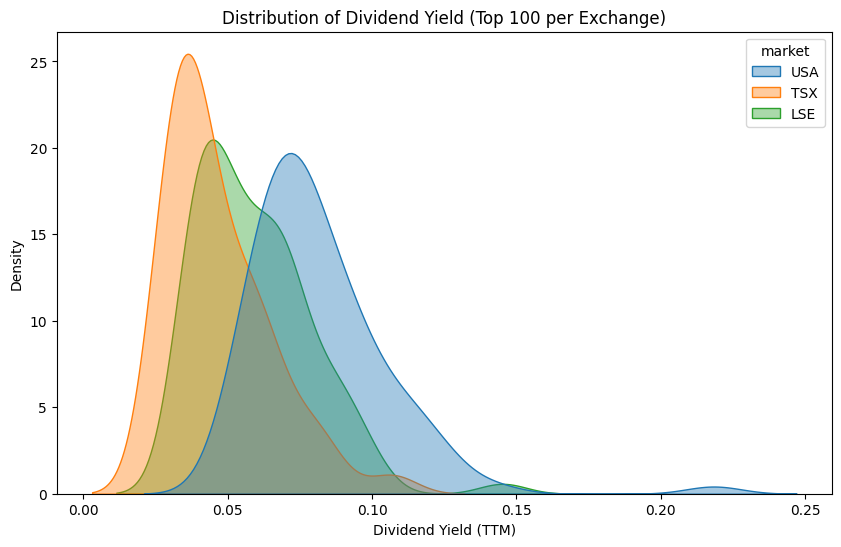

In [32]:
top_usa["market"] = "USA"
top_tsx["market"] = "TSX"
top_lse["market"] = "LSE"

df_all = pd.concat([top_usa, top_tsx, top_lse])

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_all,
    x="div_yield_ttm",
    hue="market",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Distribution of Dividend Yield (Top 100 per Exchange)")
plt.xlabel("Dividend Yield (TTM)")
plt.ylabel("Density")
plt.show()

Min DD por market:
market
LSE   -0.200000
TSX   -0.194773
USA   -0.193077
Name: max_drawdown, dtype: float64


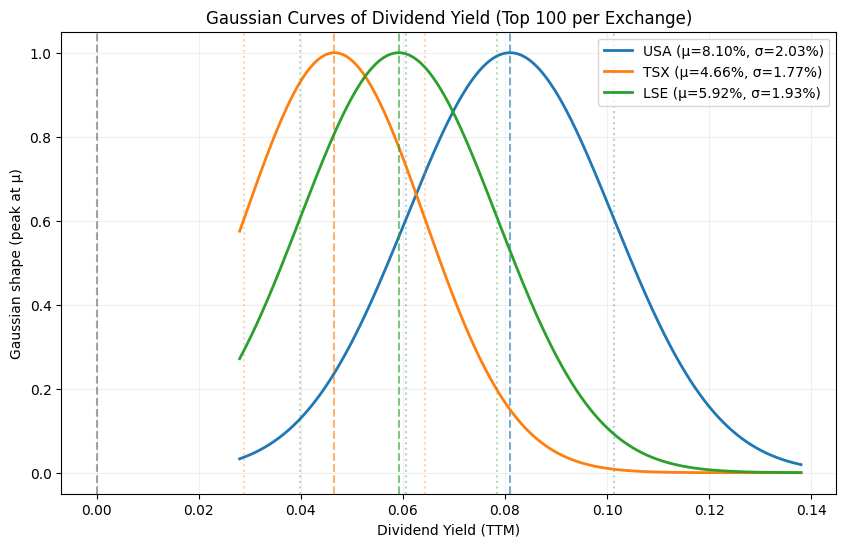

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_all_top = pd.concat([
    top_usa.assign(market="USA"),
    top_tsx.assign(market="TSX"),
    top_lse.assign(market="LSE"),
], ignore_index=True)

# sanity checks
print("Min DD por market:")
print(df_all_top.groupby("market")["max_drawdown"].min())

df_all_top["div_yield_ttm"] = pd.to_numeric(df_all_top["div_yield_ttm"], errors="coerce")
df_all_top = df_all_top.dropna(subset=["div_yield_ttm"])
df_all_top = df_all_top[df_all_top["div_yield_ttm"] > 0]

# recorta outliers extremos solo para que el eje no se destruya
hi = df_all_top["div_yield_ttm"].quantile(0.99)
df_all_top["yield"] = df_all_top["div_yield_ttm"].clip(0, hi)

markets = ["USA", "TSX", "LSE"]
colors = {"USA":"tab:blue", "TSX":"tab:orange", "LSE":"tab:green"}

x_min, x_max = df_all_top["yield"].min(), df_all_top["yield"].max()
x = np.linspace(x_min, x_max, 600)

plt.figure(figsize=(10,6))

for m in markets:
    vals = df_all_top.loc[df_all_top["market"] == m, "yield"].values
    mu = vals.mean()
    sigma = vals.std(ddof=0)
    if sigma == 0:
        continue

    # campana normal (no “density”, solo forma)
    y = np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    plt.plot(x, y, color=colors[m], linewidth=2, label=f"{m} (μ={mu:.2%}, σ={sigma:.2%})")
    plt.axvline(mu, color=colors[m], linestyle="--", alpha=0.6)          # línea de la media
    plt.axvline(mu - sigma, color=colors[m], linestyle=":", alpha=0.35)  # -1σ
    plt.axvline(mu + sigma, color=colors[m], linestyle=":", alpha=0.35)  # +1σ

# referencia en 0% (si la quieres)
plt.axvline(0, color="black", linestyle="--", alpha=0.35)

plt.title("Gaussian Curves of Dividend Yield (Top 100 per Exchange)")
plt.xlabel("Dividend Yield (TTM)")
plt.ylabel("Gaussian shape (peak at μ)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

df_all_top.to_csv("all_00_dividend_yield.csv", index=False)

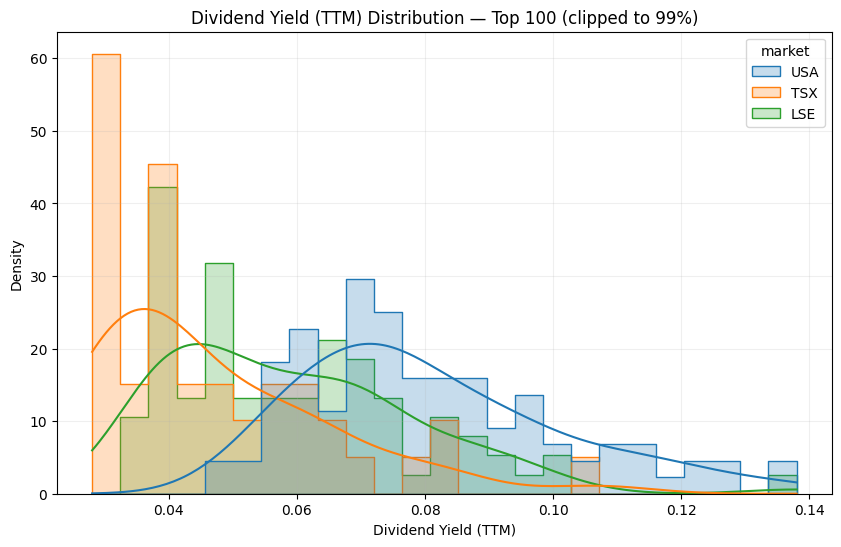

In [34]:
# recorta outliers para que no aplaste el gráfico
hi = df_all_top["div_yield_ttm"].quantile(0.99)
df_all_top["div_yield_clip"] = df_all_top["div_yield_ttm"].clip(0, hi)

plt.figure(figsize=(10,6))
sns.histplot(
    data=df_all_top,
    x="div_yield_clip",
    hue="market",
    stat="density",
    common_norm=False,
    bins=25,
    element="step",
    kde=True
)
plt.title("Dividend Yield (TTM) Distribution — Top 100 (clipped to 99%)")
plt.xlabel("Dividend Yield (TTM)")
plt.ylabel("Density")
plt.grid(True, alpha=0.2)
plt.show()


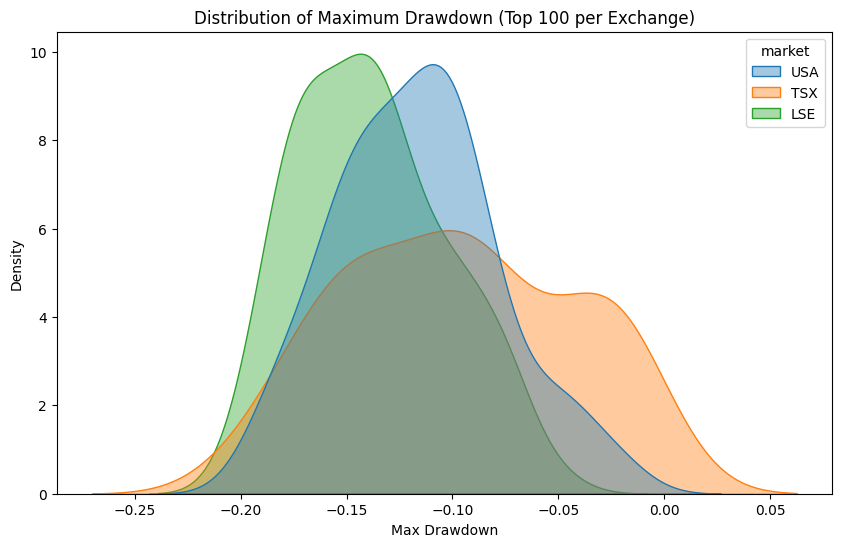

In [35]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_all_top,
    x="max_drawdown",
    hue="market",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Distribution of Maximum Drawdown (Top 100 per Exchange)")
plt.xlabel("Max Drawdown")
plt.ylabel("Density")
plt.show()

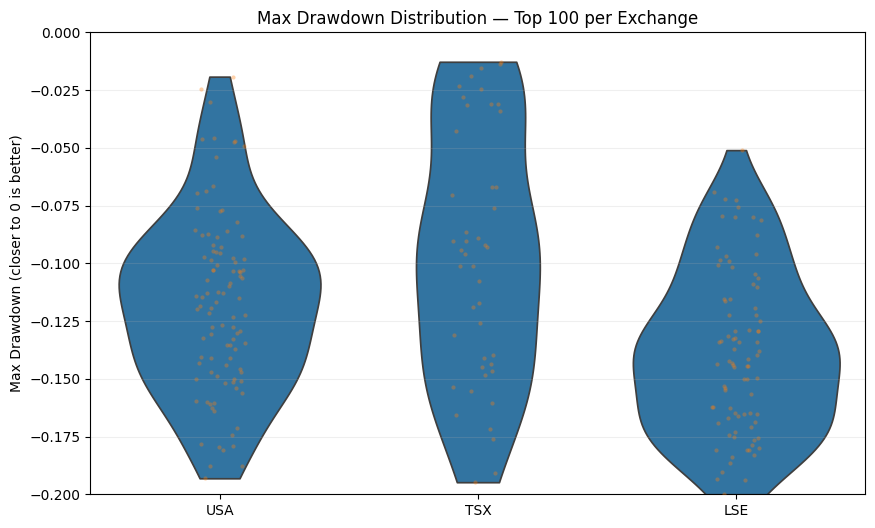

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.violinplot(data=df_all_top, x="market", y="max_drawdown", inner=None, cut=0)
sns.stripplot(data=df_all_top, x="market", y="max_drawdown", size=3, alpha=0.35)

plt.title("Max Drawdown Distribution — Top 100 per Exchange")
plt.xlabel("")
plt.ylabel("Max Drawdown (closer to 0 is better)")
plt.ylim(-0.20, 0)
plt.grid(True, axis="y", alpha=0.2)
plt.show()


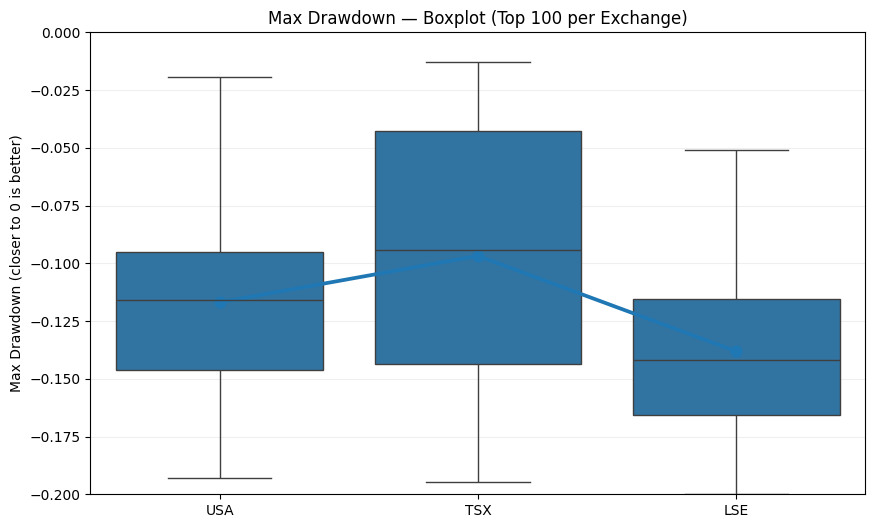

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df_all_top, x="market", y="max_drawdown", showfliers=False)
sns.pointplot(data=df_all_top, x="market", y="max_drawdown", estimator="mean", errorbar=None)

plt.title("Max Drawdown — Boxplot (Top 100 per Exchange)")
plt.xlabel("")
plt.ylabel("Max Drawdown (closer to 0 is better)")
plt.ylim(-0.20, 0)
plt.grid(True, axis="y", alpha=0.2)
plt.show()
